# Assignment 2
* In this assignment you will be working with three data files from iMDB:
    * cast.csv
    * release_dates.csv
    * titles.csv
* Using the appropriate file(s), answer the following questions
* Some questions can be completed with one-liners while others are a bit more involved
* Where appropriate, answers should also provide brief commentary
* Exclude data that doen't make senss, i.e. data from the future
* Once complete upload this notebook to your classwork Github repo and post the link on Canvas 

### 1. Conduct a high level assessment of the three data files, i.e. how many records are there, what kind of data, etc. Summarize your findings with annotation. 

In [1]:
import pandas as pd
import os

path = r"C:\Users\yshah\Documents\OIM7502_F25\data"

# Load datasets
cast = pd.read_csv(os.path.join(path, "cast.csv"))
release_dates = pd.read_csv(os.path.join(path, "release_dates.csv"))
titles = pd.read_csv(os.path.join(path, "titles.csv"))

# Show number of rows (records) and columns for each file
print("cast.csv:", cast.shape[0], "rows,", cast.shape[1], "columns")
print("release_dates.csv:", release_dates.shape[0], "rows,", release_dates.shape[1], "columns")
print("titles.csv:", titles.shape[0], "rows,", titles.shape[1], "columns")

# Check data types
print("\n--- Data Types ---")
print("\ncast.csv:")
print(cast.dtypes)
print("\nrelease_dates.csv:")
print(release_dates.dtypes)
print("\ntitles.csv:")
print(titles.dtypes)

cast.csv: 3442902 rows, 6 columns
release_dates.csv: 443486 rows, 4 columns
titles.csv: 226013 rows, 2 columns

--- Data Types ---

cast.csv:
title         object
year           int64
name          object
type          object
character     object
n            float64
dtype: object

release_dates.csv:
title      object
year        int64
country    object
date       object
dtype: object

titles.csv:
title    object
year      int64
dtype: object


### 2. How many movies have the title North by Northwest

In [3]:
len(titles.query("title == 'North by Northwest'"))



1

### 3. How many version of Hamlet are there, when was the first made? the last?

In [4]:
h = titles.query("title == 'Hamlet'")
print(f"Versions: {len(h)}, First: {h.year.min()}, Last: {h.year.max()}")




Versions: 20, First: 1910, Last: 2017


### 4. List all the movies called Treasure Island from oldest to newest

In [5]:
titles.query("title == 'Treasure Island'")[['title', 'year']].sort_values('year')



,title,year
180911,Treasure Island,1918
108853,Treasure Island,1920
87953,Treasure Island,1934
126321,Treasure Island,1950
190233,Treasure Island,1972
122150,Treasure Island,1973
52099,Treasure Island,1985
36752,Treasure Island,1999


### 5. How many movies were made in 1950? 1980? 2000? What conclusions can you draw from these data points?

In [10]:
counts = titles.year.value_counts().loc[[1950, 1980, 2000]].reset_index()
counts.columns = ['Year', 'Number of Movies']
print(counts)



   Year  Number of Movies
0  1950              1109
1  1980              1750
2  2000              2568


### 6. How big was the cast of Metropolis


In [14]:
print(len(cast[cast.title == 'Metropolis']))



33


### 7. How many roles for actors were there 1950's? 1990's

In [16]:
a50s = len(cast[(cast.year.between(1950, 1959)) & (cast.type == 'actor')])
a90s = len(cast[(cast.year.between(1990, 1999)) & (cast.type == 'actor')])
print(a50s, a90s)



153559 245713


### 8. How many roles for actors & actresses over time? Output should be a line graph

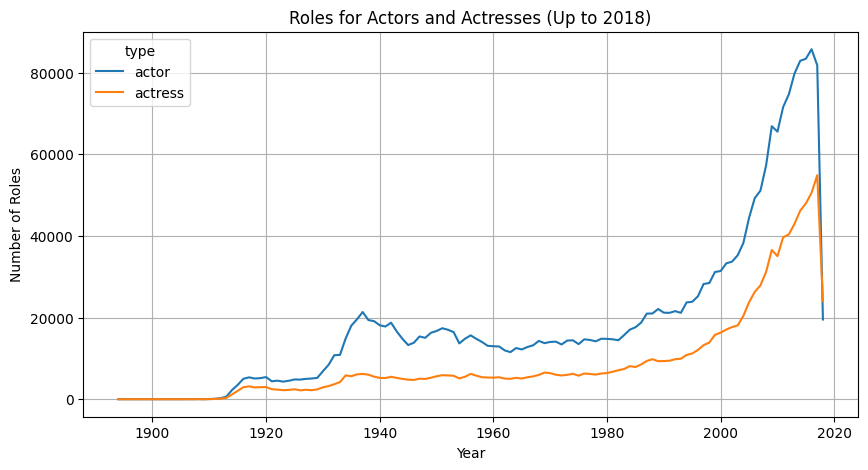

In [17]:
import matplotlib.pyplot as plt

df = cast[(cast.type.isin(['actor', 'actress'])) & (cast.year <= 2018)]
df.groupby(['year', 'type']).size().unstack(fill_value=0).plot(figsize=(10,5))

plt.title('Roles for Actors and Actresses (Up to 2018)')
plt.xlabel('Year')
plt.ylabel('Number of Roles')
plt.grid()
plt.show()



### 9. How many "leading roles" were there in the 2000's?

In [18]:
print(len(cast.query("2000 <= year < 2010 and n == 1")))


23593


### 10. How many roles received no ranking in the 2000's? 1950's. What conclusions can you draw from these two data points?

In [19]:
a = lambda s,e: len(cast[(cast.year.between(s, e - 1)) & (cast.n.isna())])
print("2000s:", a(2000, 2010))
print("1950s:", a(1950, 1960))



2000s: 232037
1950s: 95406


In [ ]:
# There were more unranked roles in the 2000s than in the 1950s, showing that films today have larger casts and more roles without ranking.

### 11. Plot the number of films made in each decade

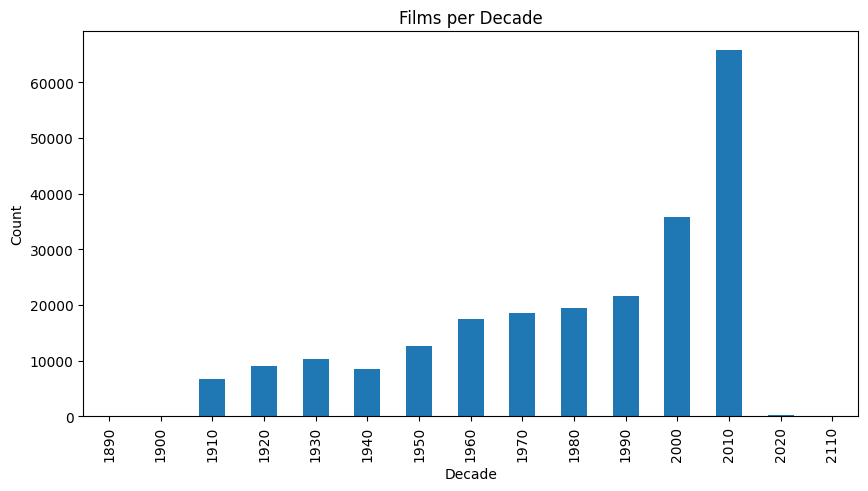

In [20]:
titles.year //= 10
titles.year *= 10
titles.groupby('year').size().plot.bar(title='Films per Decade', figsize=(10,5))
plt.xlabel('Decade')
plt.ylabel('Count')
plt.show()



### 12. Plot the number of films with a Rustler character over time

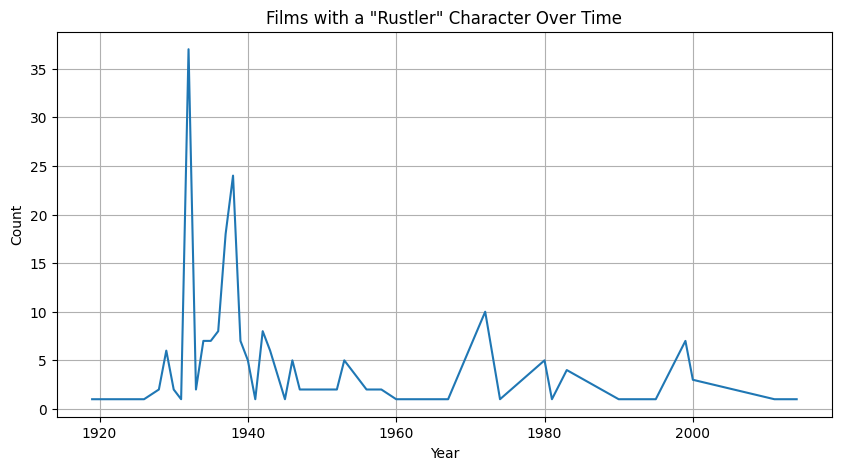

In [23]:
cast[cast.character.str.contains('Rustler', case=False, na=False)] \
    .groupby('year').size().plot(figsize=(10,5), title='Films with a "Rustler" Character Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid()
plt.show()


### 13. What are the top ten character names of all time?

In [35]:
top_characters = cast['character'].value_counts().head(10)
print(top_characters)


character
Himself        19637
Dancer         12019
Extra          10848
Reporter        7818
Doctor          6963
Party Guest     6786
Student         6631
Policeman       6424
Bartender       6290
Herself         6269
Name: count, dtype: int64


### 14. Which actor appeared in the most films in the 1990's decade?

In [25]:
a = cast.query("1990 <= year < 2000 and type == 'actor'")['name'].value_counts()
print(f"{a.index[0]}: {a.iloc[0]}")



Shakti Kapoor: 143


### 15. What are the top 10 roles that start with Science?

In [27]:
sci = cast.character.dropna()
top_sci = sci[sci.str.startswith('Science')].value_counts().head(10)
for name, count in top_sci.items():
    print(f"{name}: {count}")


Science Teacher: 57
Science Fair Student: 9
Science Student: 6
Science Fair Judge: 6
Science Reporter: 5
Science Fair Kid: 5
Science Kid: 5
Science: 4
Science Fair Teacher: 3
Science teacher: 3


### 16. What film has the largest cast

In [28]:
x = cast.groupby(['title', 'year']).size().sort_values(ascending=False).head(1)
title, year = x.index[0]
count = x.iloc[0]
print(f"{title} ({year}): {count} cast members")


Around the World in 80 Days (1956): 1299 cast members


### 17. Generate descriptive statistics for cast size. Briefly comment on the results

In [29]:
print(cast.groupby(['title','year']).size().describe())



count    182497.000000
mean         18.865494
std          21.241247
min           1.000000
25%           6.000000
50%          13.000000
75%          24.000000
max        1299.000000
dtype: float64


In [ ]:
# Most films have relatively small casts; the median is 13 and the average about 19. The standard deviation of 21 shows that means cast sizes vary a lot.

### 18. How many films has Natalie Portman been in in each year throughout her career?

In [30]:
n = cast[cast.name == 'Natalie Portman'].groupby('year').size()
print(n.to_string())


year
1995    1
1996    3
1999    3
2000    1
2001    1
2002    1
2003    1
2004    2
2005    4
2006    2
2007    3
2008    1
2009    2
2010    4
2011    3
2013    1
2015    4
2016    3
2017    1


### 19. How many films did Natalie Portman appear in each year where where she was either the top star or co-star?

In [31]:
n = cast[(cast.name == 'Natalie Portman') & (cast.n.isin([1, 2]))].groupby('year').size()
print(n.to_string())


year
1999    1
2000    1
2002    1
2005    3
2006    2
2007    1
2008    1
2009    1
2010    2
2011    2
2013    1
2015    2
2016    2


### 20. Determine how many roles for actor or actress by decade. Plot the output 

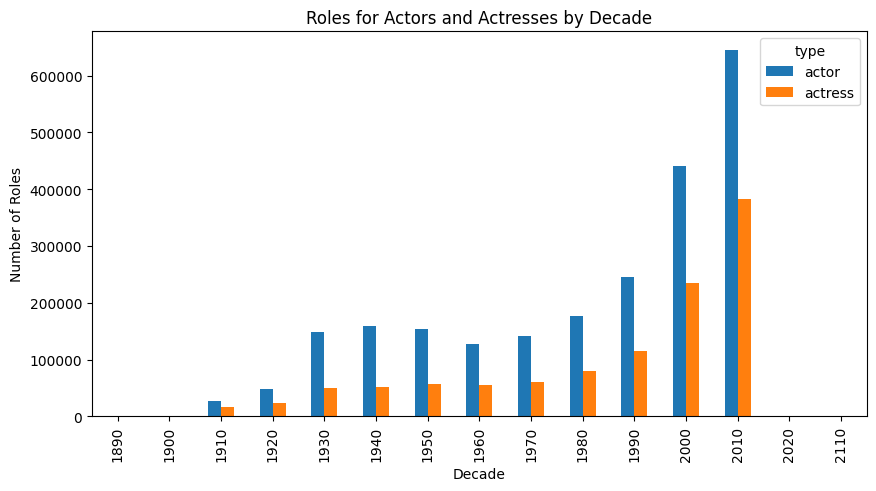

In [32]:
df = cast.query("type in ['actor','actress']").assign(decade=(cast.year//10)*10)
df.groupby(['decade','type']).size().unstack(fill_value=0).plot.bar(
    figsize=(10,5), title='Roles for Actors and Actresses by Decade'
)
plt.xlabel('Decade')
plt.ylabel('Number of Roles')
plt.show()


### 21. Determine and comment on the day of the week that movies are released. What is notable about release days and months throughout the year? (Use pd.pivot_table)

In [34]:
pivot = release_dates.pivot_table(index='day', values='title', aggfunc='count')


KeyError: 'day'

### 22. Can you plot the pivot table? Is the output "correct"? Can you fix it?

### 23. What films did actors in Star Wars go on to appear in? 

In [36]:
sw = cast[cast.title.str.contains('Star Wars', case=False, na=False)]
actors = sw.name.unique()
print(len(actors))
print(cast[cast.name.isin(actors) & ~cast.title.str.contains('Star Wars', case=False, na=False)][['name','title','year']].head())




944
                 name                 title  year
3900  Ian Abercrombie  Addams Family Values  1993
3901  Ian Abercrombie   Blasphemy the Movie  2001
3902  Ian Abercrombie      Chromiumblue.com  2003
3903  Ian Abercrombie           Clean Slate  1994
3904  Ian Abercrombie            Firewalker  1986
